## Problem statement

Use unsupervised learning to groupe the gene expressions of patients with different types of tumors. Breast cancer, Kidney tumor/ renal , colon cancer, lung cancer, prostate cancer 

### Importing libraries 

In [ ]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold


> note

the main problem of k means clustering is you have to specify the number of clusters, for heirarchical you dont need to specify the number of clusters. 

**agglomerative** - bottom up approach

**divisive** -  top - down approach



| Image | Link |
| :--- | :--- |
| 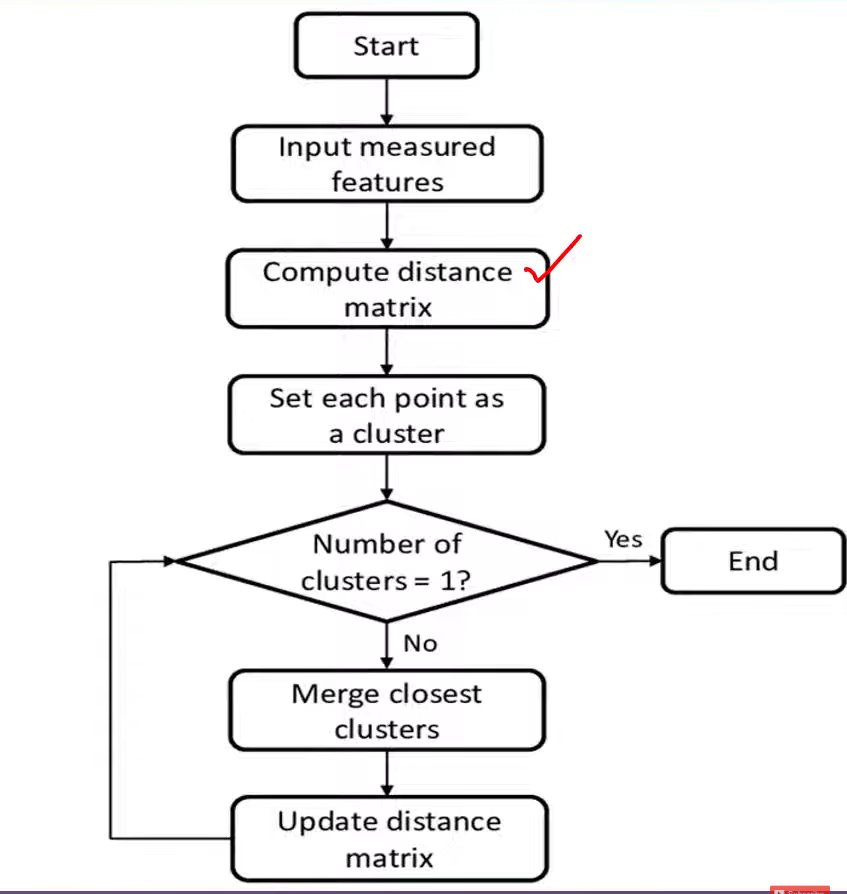 | [Watch on YouTube](https://www.youtube.com/watch?v=i6XIu-H2gOc&list=PLpmY-bsmBBXpgHSx0yJD0o6oUOjqEHB1m) |


### loading the data

In [4]:
df = pd.read_csv(r"C:\Users\User\Desktop\Data-Science-Class\Data\data.csv")
df.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_16373,gene_16374,gene_16375,gene_16376,gene_16377,gene_16378,gene_16379,gene_16380,gene_16381,gene_16382
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0,7.175175,0.591871,0.0,...,8.750533,7.421257,4.692126,1.334282,1.650856,3.973382,0.000000,9.291933,0.840926,7.886642
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0,6.816049,0.000000,0.0,...,6.638879,7.991732,5.709045,0.811142,2.717824,3.255773,1.590818,3.467410,1.178045,8.864223
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0,6.972130,0.452595,0.0,...,8.205754,10.375778,1.839758,0.000000,3.004897,0.796598,0.000000,5.533710,0.225892,9.843799
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0,7.843375,0.434882,0.0,...,8.093185,8.424771,5.502251,0.434882,2.207862,1.039419,0.000000,8.358278,0.377401,7.701320
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0,6.566967,0.360982,0.0,...,7.522228,12.176650,10.305423,0.360982,1.099497,0.360982,0.649386,9.315607,1.052833,10.646325


In [5]:
df.shape

(801, 16384)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 16384 entries, Unnamed: 0 to gene_16382
dtypes: float64(16351), int64(32), str(1)
memory usage: 100.1 MB


In [7]:
df.isna().sum()

Unnamed: 0    0
gene_0        0
gene_1        0
gene_2        0
gene_3        0
             ..
gene_16378    0
gene_16379    0
gene_16380    0
gene_16381    0
gene_16382    0
Length: 16384, dtype: int64

In [8]:
df.describe()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_16373,gene_16374,gene_16375,gene_16376,gene_16377,gene_16378,gene_16379,gene_16380,gene_16381,gene_16382
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.0,801.000000,801.000000,801.000000,801.000000,...,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,3.010909,3.095350,6.722305,9.813612,0.0,7.405509,0.499882,0.016744,0.013428,...,7.603795,9.353000,6.590923,0.541963,3.142053,1.710593,2.912340,7.229904,1.250715,9.659116
std,0.136850,1.200828,1.065601,0.638819,0.506537,0.0,1.108237,0.508799,0.133635,0.204722,...,0.946110,1.098303,2.126161,0.826818,3.210868,1.473575,3.673102,3.239120,1.568535,1.073619
min,0.000000,0.000000,0.000000,5.009284,8.435999,0.0,3.930747,0.000000,0.000000,0.000000,...,4.343664,6.321394,1.839758,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.847371
25%,0.000000,2.299039,2.390365,6.303346,9.464466,0.0,6.676042,0.000000,0.000000,0.000000,...,7.138722,8.668126,4.990873,0.000000,1.209079,0.631058,0.410233,4.733490,0.000000,8.894987
50%,0.000000,3.143687,3.127006,6.655893,9.791599,0.0,7.450114,0.443076,0.000000,0.000000,...,7.627585,9.211976,6.036009,0.360982,1.993928,1.371280,1.169155,7.622132,0.710790,9.555136
75%,0.000000,3.883484,3.802534,7.038447,10.142324,0.0,8.121984,0.789354,0.000000,0.000000,...,8.143271,9.970681,8.346159,0.816395,3.078627,2.413865,3.996832,10.010011,1.957655,10.303804
max,1.482332,6.237034,6.063484,10.129528,11.355621,0.0,10.718190,2.779008,1.785592,4.067604,...,12.009825,14.576024,11.651756,9.770221,11.940079,8.041873,13.842124,13.875874,8.039901,13.515601


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_16373,gene_16374,gene_16375,gene_16376,gene_16377,gene_16378,gene_16379,gene_16380,gene_16381,gene_16382
0,0.0,2.017209,3.265527,5.478487,10.431999,0,7.175175,0.591871,0.0,0.0,...,8.750533,7.421257,4.692126,1.334282,1.650856,3.973382,0.000000,9.291933,0.840926,7.886642
1,0.0,0.592732,1.588421,7.586157,9.623011,0,6.816049,0.000000,0.0,0.0,...,6.638879,7.991732,5.709045,0.811142,2.717824,3.255773,1.590818,3.467410,1.178045,8.864223
2,0.0,3.511759,4.327199,6.881787,9.870730,0,6.972130,0.452595,0.0,0.0,...,8.205754,10.375778,1.839758,0.000000,3.004897,0.796598,0.000000,5.533710,0.225892,9.843799
3,0.0,3.663618,4.507649,6.659068,10.196184,0,7.843375,0.434882,0.0,0.0,...,8.093185,8.424771,5.502251,0.434882,2.207862,1.039419,0.000000,8.358278,0.377401,7.701320
4,0.0,2.655741,2.821547,6.539454,9.738265,0,6.566967,0.360982,0.0,0.0,...,7.522228,12.176650,10.305423,0.360982,1.099497,0.360982,0.649386,9.315607,1.052833,10.646325


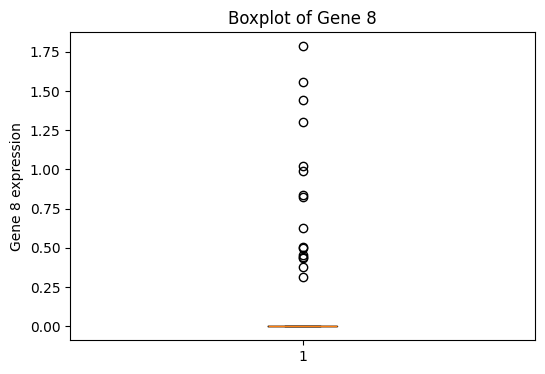

In [11]:
plt.figure(figsize=(6,4))
plt.boxplot(df['gene_8'], vert=True)
plt.title('Boxplot of Gene 8')
plt.ylabel('Gene 8 expression')
plt.show()

In [12]:
# This scaling of every data before variance threshold
df_before = df.copy()

In [ ]:
scaler = StandardScaler()
df_before_scaled = scaler.fit_transform(df_before)

In [14]:
print(df_before_scaled[:5])

[[-0.19479935 -0.82802988  0.15980044 ...  0.63699936 -0.26141892
  -1.65196526]
 [-0.19479935 -2.01501735 -1.415042   ... -1.16230501 -0.04635868
  -0.74084865]
 [-0.19479935  0.41734754  1.15673547 ... -0.52398623 -0.65377155
   0.17212602]
 [-0.19479935  0.54388843  1.32618236 ...  0.34857577 -0.55711816
  -1.82468666]
 [-0.19479935 -0.29595452 -0.25710728 ...  0.64431278 -0.12623599
   0.92008893]]


In [ ]:
pca = PCA() # leave n_components=None to see how many components are needed to explain 95% of the variance
df_before_pca = pca.fit_transform(df_before_scaled)

# Print the cumulative explained variance ratio to see how much variance is captured by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance per Component:")
print(cumulative_variance)

# Find how many components are needed to explain at least 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components needed to explain 95% of the variance: {n_components_95}")

Cumulative Explained Variance per Component:
[0.10715262 0.19249482 0.27042212 0.32260542 0.36390504 0.39272032
 0.41595861 0.4375387  0.45366606 0.46632096 0.47692915 0.48588806
 0.49447866 0.50207808 0.50867467 0.51505405 0.52103793 0.52686085
 0.53212814 0.53725006 0.54211929 0.54676648 0.55124549 0.55568409
 0.55991633 0.56409188 0.56800515 0.57190244 0.57567619 0.57933553
 0.58290383 0.58640999 0.58981375 0.59308963 0.59629854 0.59950051
 0.60258116 0.60549398 0.60833117 0.61113158 0.61388897 0.61654876
 0.61919445 0.62179529 0.62435182 0.62689004 0.62941331 0.63185664
 0.63428327 0.63663253 0.63896832 0.64125139 0.64350833 0.64572686
 0.64787508 0.65001477 0.65212102 0.65417912 0.65622267 0.65824189
 0.66023627 0.66221219 0.66416065 0.66608252 0.66798394 0.66982032
 0.67162614 0.67341727 0.67519044 0.67695529 0.67868823 0.68040505
 0.68211258 0.68377707 0.68543677 0.6870512  0.68864059 0.69021917
 0.69177091 0.69331709 0.694855   0.6963535  0.69784668 0.69932868
 0.70078096 0.702

In [16]:
df_after = df.copy()

In [ ]:
selector = VarianceThreshold(threshold=0)
df_after_threshold = selector.fit_transform(df_after)
print(df_after_threshold.shape)
print(df_after.shape)

(801, 16351)
(801, 16383)


In [18]:
20531 - 20264 # 267 features have been removed after variance threshold

267

In [19]:

df_after_threshold_scaled = scaler.fit_transform(df_after_threshold)

In [20]:
# apply pca for dimentionality reduction
pca = PCA() # leave n_components=None to see how many components are needed to explain 95% of the variance
df_after_threshold_scaled_pca = pca.fit_transform(df_after_threshold_scaled)

# Print the cumulative explained variance ratio to see how much variance is captured by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance per Component:")
print(cumulative_variance)

# Find how many components are needed to explain at least 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components needed to explain 95% of the variance: {n_components_95}")

Cumulative Explained Variance per Component:
[0.10715262 0.19249482 0.27042212 0.32260542 0.36390504 0.39272032
 0.41595861 0.4375387  0.45366606 0.46632096 0.47692915 0.48588806
 0.49447866 0.50207808 0.50867467 0.51505405 0.52103793 0.52686085
 0.53212814 0.53725006 0.54211929 0.54676648 0.55124549 0.55568409
 0.55991633 0.56409188 0.56800515 0.57190244 0.57567619 0.57933553
 0.58290383 0.58640999 0.58981375 0.59308963 0.59629854 0.59950051
 0.60258116 0.60549398 0.60833117 0.61113158 0.61388897 0.61654876
 0.61919445 0.62179529 0.62435182 0.62689004 0.62941331 0.63185664
 0.63428327 0.63663253 0.63896832 0.64125139 0.64350833 0.64572686
 0.64787508 0.65001477 0.65212102 0.65417912 0.65622267 0.65824189
 0.66023627 0.66221219 0.66416065 0.66608252 0.66798394 0.66982032
 0.67162614 0.67341727 0.67519044 0.67695529 0.67868823 0.68040505
 0.68211258 0.68377707 0.68543677 0.6870512  0.68864059 0.69021917
 0.69177091 0.69331709 0.694855   0.6963535  0.69784668 0.69932868
 0.70078096 0.702

In [23]:
pca_final = PCA(n_components=528) # applying pca with the known principle components 
df_reduced = pca_final.fit_transform(df_after_threshold_scaled)
print(df_reduced.shape)


(801, 528)


In [24]:
df_A_clustering = df_reduced.copy()


### Build the dendogarm
we build the dendogram first then decide how many clusters make sense. 

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Build the hierarchical tree

''' the linkage is where the hierarchical tree is created 
    it records: who merged, when they merged and distance which they merged 
    no clusters are assigned yet - it only builds the tree 
    ward - linkage method - Ward's method creates tight, neat gene groups by picking 
    combinations that add the least messiness.'''
linked = linkage( 
    df_A_clustering,
    method="ward"
)

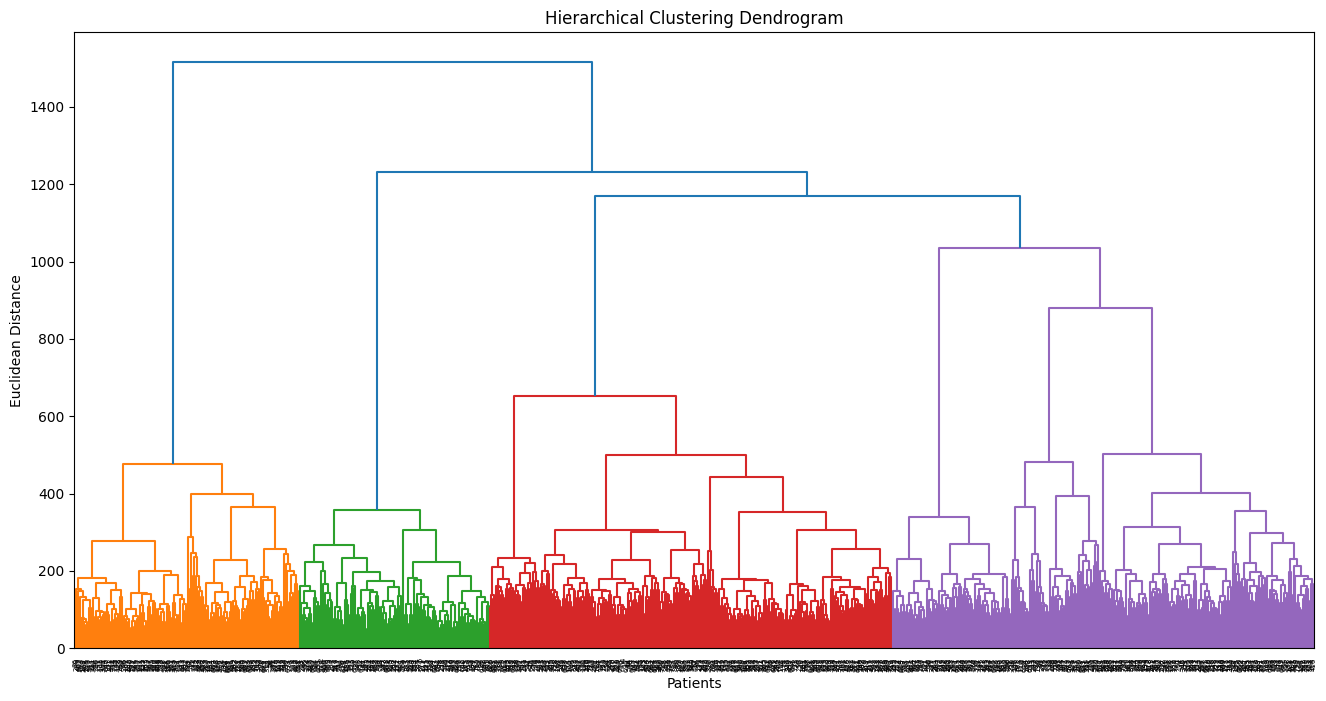

In [26]:
plt.figure(figsize=(16,8))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patients")
plt.ylabel("Euclidean Distance") # the y axis is the euclidean distance

plt.show()

 the algorithm is joining patients that are very similar - look at the merges before 200

 The dendrogram was used to determine a suitable number of clusters before fitting the Agglomerative Clustering model. By examining the hierarchical tree, four major branches can be clearly identified before the highest-level merges occur. Each of these branches represents a large group of patients that has already been formed through multiple successive merges of highly similar samples. Within each branch, patients are merged at relatively low linkage distances, indicating that their gene expression profiles are similar. However, these four large branches remain separate until much higher linkage distances, where the algorithm begins merging entire groups rather than individual patients. These higher-level merges suggest that the groups being combined are substantially more dissimilar than the patients within each group. Therefore, the four major branches appear to represent the most distinct natural groupings in the dataset before the algorithm starts combining broader clusters. Based on this visual structure, four clusters were selected as an appropriate starting point for Agglomerative Clustering, as they preserve the major patterns present in the data while avoiding the merging of already well-separated groups.


In [43]:
from sklearn.cluster import AgglomerativeClustering

agglomerative = AgglomerativeClustering(
    n_clusters=5,        # Suggested by the dendrogram
    metric="euclidean",
    linkage="ward"
)

cluster_labels = agglomerative.fit_predict(df_A_clustering)

print(cluster_labels)

[0 0 2 2 1 2 3 2 1 2 1 3 2 0 1 1 0 3 3 2 1 3 0 1 3 0 4 1 1 0 1 1 3 0 2 1 3
 0 0 0 3 2 2 3 3 1 0 4 1 0 1 0 1 2 4 0 1 4 3 1 0 3 1 0 2 4 1 2 3 1 3 1 1 0
 1 0 1 3 2 4 1 2 1 1 0 2 1 0 3 1 2 2 1 0 1 2 4 1 2 1 1 3 1 3 0 3 0 4 0 0 0
 1 0 2 1 3 3 3 1 1 0 3 0 1 2 2 2 1 3 1 4 0 4 1 1 3 0 1 3 4 1 2 1 3 0 4 0 1
 0 0 0 0 1 1 0 1 1 2 2 0 0 0 3 1 2 0 4 3 0 1 3 0 1 0 1 0 1 2 1 3 4 3 1 2 2
 2 0 0 1 0 0 3 0 2 0 1 0 1 0 0 1 3 3 3 3 2 0 2 1 0 0 1 2 1 2 1 1 1 0 1 3 0
 3 3 0 1 3 2 1 0 0 2 4 0 3 2 3 4 1 3 3 0 2 1 0 0 3 1 1 4 1 2 4 1 2 3 0 2 2
 1 4 4 0 4 4 2 0 1 1 3 3 1 4 0 3 2 1 1 3 1 1 1 0 0 0 1 1 1 3 3 3 3 0 1 1 3
 1 1 0 2 1 1 4 0 2 1 1 1 4 0 2 1 4 0 0 2 3 0 3 3 1 4 3 1 1 1 1 3 1 1 2 1 3
 1 0 2 3 1 2 4 1 1 1 0 0 0 1 1 2 0 1 3 1 4 4 0 1 3 1 1 1 4 0 4 3 2 3 1 1 3
 1 4 2 0 2 0 3 2 1 4 3 3 4 4 2 1 1 4 3 0 2 0 1 1 0 0 1 0 1 3 4 2 1 0 2 0 0
 1 0 1 0 2 1 2 4 1 0 1 1 0 1 1 1 3 0 2 1 2 3 0 3 4 1 2 0 3 1 1 3 1 0 0 1 2
 4 1 3 0 0 1 2 1 1 1 1 3 0 1 3 1 1 0 0 3 4 2 4 0 3 3 0 2 3 4 0 0 1 2 2 1 2
 0 3 2 1 0 2 0 1 1 4 0 3 

In [44]:
# Is the df_A_clustering a DataFrame or an array? 
# What is the shape of the df_A_clustering? 
# What is the type of cluster_labels? 
# How many cluster labels are there?

print(type(df_A_clustering))
print(df_A_clustering.shape)
print(type(cluster_labels))
print(len(cluster_labels))

<class 'numpy.ndarray'>
(801, 528)
<class 'numpy.ndarray'>
801


### Error Analysis

In [45]:
# Make a new DataFrame with the cluster labels and check the distribution of the labels

df_with_labels = pd.DataFrame(df_A_clustering)
df_with_labels['cluster_labels'] = cluster_labels
print(df_with_labels['cluster_labels'].value_counts())

cluster_labels
1    260
0    196
3    145
2    123
4     77
Name: count, dtype: int64


Cluster 0 has 273 patients
Cluster 1 has 260 patients
Cluster 3 has 145 patients
Cluster 2 has 123 patients
Cluster 4 has 77 patients

In [46]:
# Compute the mean of each feature for each cluster to understand the characteristics of each cluster

cluster_means = df_with_labels.groupby('cluster_labels').mean()
print(cluster_means)

                        0          1          2          3          4  \
cluster_labels                                                          
0               11.485304  15.492455 -18.315593  20.920391  19.405096   
1                9.154896 -38.234709   6.932741  15.562812 -10.788141   
2               18.311366  21.215289  59.929097 -23.994115  16.521926   
3              -73.284753  23.007982 -10.612116 -10.329448 -18.234982   
4               48.605177  12.452797 -52.534787 -48.021844  -5.020868   

                        5         6          7          8         9  ...  \
cluster_labels                                                       ...   
0               -5.955318 -8.609173  -9.221043  -0.282542 -5.243902  ...   
1                1.661885  3.515893   3.447800  -1.101369  0.778709  ...   
2               -8.079730  4.965022  -1.141551   0.280881  5.046223  ...   
3                1.374599  2.811615  -3.565575  -3.298379  1.027438  ...   
4               19.865482 -3.183

The dendogram lets the data suggesta suitable number of clusters 


In [47]:
cross_tab = pd.crosstab(index=df_with_labels['cluster_labels'], columns='count')
print(cross_tab)

col_0           count
cluster_labels       
0                 196
1                 260
2                 123
3                 145
4                  77


### Validate

In [51]:
# Read the true labels

true_labels_df = pd.read_csv(r"C:\Users\User\Desktop\Data-Science-Class\Data\labels.csv", index_col=0)  # Assuming the first column is an index and should be ignored

# Extract the true labels
true_classes = true_labels_df['Class']

# Create confusion matrix to compare the clustering results with the true labels
cross_tab = pd.crosstab(index=df_with_labels['cluster_labels'], columns=true_classes.values)
print(cross_tab)

col_0           BRCA  COAD  KIRC  LUAD  PRAD
cluster_labels                              
0                 44     1     0   139    12
1                256     0     1     2     1
2                  0     0     0     0   123
3                  0     0   145     0     0
4                  0    77     0     0     0


## Insights

### The Perfect/Clean Clusters

Cluster 2 is Prostate Cancer (PRAD) 123 samples matched perfectly
Cluster 3 is Kidney Cancer (KIRC) 145 samples matched perfectly
Cluster 4 is Colon Cancer (COAD) 77 samples matched perfectly

### The Dominant Cluster

Cluster 1 is Breast Cancer (BRCA) Captured 256 of the samples with almost 0 noise

### The Mixed/Imperfect Cluster

Cluster 0 is primarily Lung Cancer 139 samples
There is however, spillover as 44 Breast Cancer (BRCA) and 12 Prostate Cancer (PRAD) in the same cluster

44 of the breast cancer samples and 12 of the prostate cancer samples have gene expression profiles look remarkably similar to lung cancer

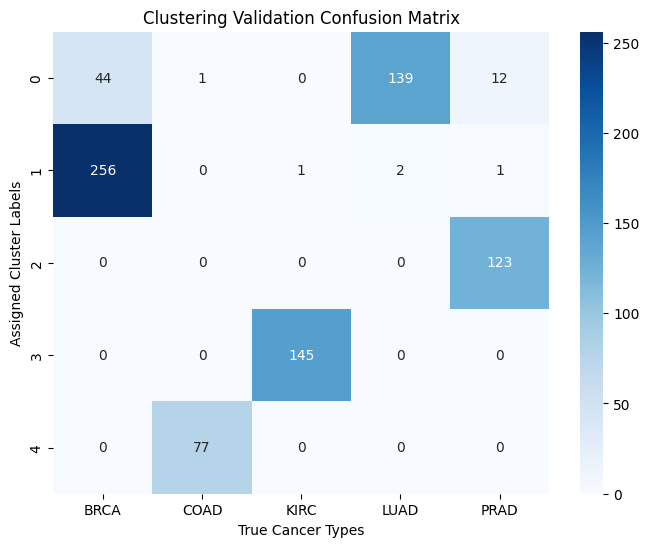

In [53]:
# Visualize the Overlap between the clustering results and the true labels using a heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Clustering Validation Confusion Matrix")
plt.xlabel("True Cancer Types")
plt.ylabel("Assigned Cluster Labels")
plt.show()